# Module 1 — The Modelling Workflow: Splits, Pipelines, Cross-Validation & Leakage

## Why you're here: what the model is for
- A Portuguese bank has a list of clients it could phone to sell a savings
  product. Calling costs time and money, and most people say no (88.3%).
- The bank would like to know, **before calling**, which clients are most likely
  to say yes, so it can call those first.
- A **model** learns from past clients whose answer is already known (the column
  `subscribed`: 1 = said yes, 0 = said no). Then, for a client not yet called, it estimates
  how likely that client is to say yes.
- The 16 other columns (age, job, balance, and so on) are the information the
  model uses to make that estimate.

**Your endgame in this module:** learn to build that estimate, and above all to
**check honestly how good it is**, because the easiest mistakes make a model
look far better than it will really be.

## From the curriculum

> ### <u>Module 1 — The Modelling Workflow: Splits, Pipelines, Cross-Validation & Leakage</u>
>
> **Concepts**
> - Train/test split: why a model is judged on rows it never saw, and why the
>   split is stratified (so both parts keep the same target rate)
> - `Pipeline` and `ColumnTransformer`: preprocessing and model as one object, so
>   every preprocessing step is fitted on training rows only
> - Cross-validation (CV): k train/test splits instead of one, to average out
>   the luck of a single split
> - Data leakage, three kinds: (1) a feature that is only known *after* the
>   outcome; (2) preprocessing fitted on all rows before splitting; (3) a random
>   split when the real use is predicting the *future*
>
> **Why it matters**
> A leaky model looks excellent in the notebook and fails in production, and the
> analyst who shipped it owns that failure. Every later module's evaluation is
> only as honest as this workflow.
>
> **Worked example**
> Bank Marketing: predicting whether a call ends in a subscription. With the
> call's `duration` as a feature, 5-fold CV gives an AUC (area under the ROC
> curve, defined in the notebook) of about 0.91. Without it, about 0.77. But
> duration is only known once the call has ended, i.e. after the outcome. The
> 0.91 model cannot exist at decision time.
>
> **Resources**
> - [Common pitfalls and recommended practices, §12.2 Data leakage](https://scikit-learn.org/stable/common_pitfalls.html)
>   (scikit-learn user guide, ~15 min, verified).
> - [Leakage in Data Mining: Formulation, Detection, and Avoidance](https://dl.acm.org/doi/10.1145/2382577.2382579)
>   (Kaufman, Rosset, Perlich & Stitelman, ACM TKDD 2012, verified). Skim
>   sections 1–2 (~20 min): the standard definition of leakage, with real
>   competition examples.
>
> **Exercise type:** find-the-leak drills: given a set of candidate features and
> preprocessing steps, classify each as safe or leaky and say why.
>
> **Interview angle:** "Your model has 99% accuracy. What do you check first?" /
> "How would you validate this model?"

## Lesson

### What a model is, in plain terms
1. **Rows and a target.** Each row is one client. One column, the **target** (`subscribed`
   here), records what happened: 1 = the client said yes, 0 = no.
2. **A model** is a formula that learns, from rows where the answer is known,
   how the other columns relate to the target. Given a new row, it outputs a
   **score** between 0 and 1: how likely that row is to be a 1.
3. **Training** (scikit-learn calls it **fitting**) is that learning step. The
   model looks at rows with known answers and adjusts its formula to match them.
   In code: `model.fit(rows, answers)`.
   By convention, code stores the input columns in a variable called `X` and
   the answers in `y`. So `X_train` means the training
   rows' input columns, and `y_train` means those same rows' answers.
4. **Why hide rows.** A model always looks good on rows it trained on, because it
   has partly memorised them. So before training we deliberately set aside some
   rows, the **test rows**, and don't show them to the model. At the end, the
   model scores them and we compare its scores with the real answers. That's
   its grade. The rows it does learn from are the **training rows**.
5. **Preprocessing.** The model only does arithmetic on numbers, but the raw data
   has text (`job` = "technician"). Preprocessing means converting the raw columns
   into numbers the model can use, before it sees them. Two conversions here:
   - **text into 0/1 columns** (called *one-hot encoding*): `job` becomes a
     "job is technician" column (1 or 0), a "job is retired" column, and so on;
   - **numbers onto one common scale**: age (about 41 on average) and account balance
     (about 1,360 euros on average) are very different sizes, so both get rescaled.
6. **Scaler.** The tool that does the rescaling (`StandardScaler`). To do it, it
   first calculates the average and spread of each **input column** (such as
   balance), *from the rows it's given*. So the scaler learns something from data
   too.
7. **The risk.** If the scaler calculates that average from *all* rows, the
   hidden test rows have influenced something the model uses. The grade is no
   longer on truly unseen rows.
8. **Pipeline.** A `Pipeline` bundles the preprocessing and the model into one
   object, so a single `.fit(training rows)` makes *every* step learn from the
   training rows only. Inside it, a `ColumnTransformer` sends the numeric
   columns to the scaler and the text columns to the 0/1 conversion.

The model used throughout this module is **logistic regression**. Module 2 opens
it up. Here, treat it as a formula that turns a row into a score between 0 and 1.

### Stratified split
When we hide 20% of the rows, **stratified** means we keep the share of "yes"
answers the same in both parts: 11.7% in the training rows and 11.7% in the test
rows. Without it, the hidden 20% could end up with, say, 10% or 13% yes-answers
by luck, and the grade would partly reflect that luck.
This applies to random splits only. If rows are hidden by date instead, each
period keeps its real yes-rate, since a difference between periods is real, not
luck.

### Cross-validation (CV)
Hiding one 20% chunk gives one grade, and that chunk might happen to be easier
or harder than usual. **Cross-validation** repeats the exercise. Cut the rows into
5 equal chunks (called **folds**). Then 5 times over: hide one fold, train on the
other 4, grade on the hidden one. Each fold gets hidden exactly once. You end up
with 5 grades, and their average is the **CV score**. It's steadier than any single
grade, and the spread of the 5 shows how much luck was involved.

### How the model is graded here: AUC
The model gives every row a score between 0 and 1. **AUC** (short for ROC-AUC,
the Area Under the Receiver Operating Characteristic curve; the long name is
historical and not needed here) grades how well those scores *rank* the rows:

*Pick one random client who said yes and one random client who said no. AUC is
how often the model gives the yes-client the higher score.*

0.5 means no better than a coin flip; 1.0 means it always ranks them correctly.
Part 1 checks this definition by counting, and shows why we don't grade with
plain accuracy. Module 4 covers AUC fully.

### Data leakage
**Leakage** means information the model won't have when it's actually used
sneaks into its training. The grade then looks great, and the model
disappoints in real use. Three kinds, each measured in Parts 3–5:
1. **A column that's only known after the outcome.** Here: how long the call
   lasted, which you only know once the call is over.
2. **Preprocessing that learns from all rows before they're split** (point 7
   above), so the hidden rows influence the model.
3. **Rows dated after the ones being graded.** When the data spans several
   periods, a random split lets the model train on later rows and be graded on
   earlier ones. That's a view of the future it won't have in real use. This
   applies only when rows come from different dates; with a single snapshot, a
   random split is fine.

### Part 0 — The data, and its quality issues up front
**Bank Marketing** (UCI, CC BY 4.0). A Portuguese bank phoned clients to sell a
**term deposit**: a savings product where you lock money away for a fixed period
in exchange for interest.

- **One row = one client in one campaign**, described by the *last* call made
  to them in that campaign. `campaign` counts every call to that client, including
  the last one.
- **45,211 rows**, from May 2008 to November 2010, stored in date order.
- **Target `subscribed`** (called `y` in the original file, renamed here for
  readability): 1 if the client subscribed (11.7% of rows), 0 if not.
- **Why this dataset** (and not the credit data used from Module 2 on): it has a
  *real*, documented leaky column, `duration`.

| Column | Meaning | Example (row 1) |
|---|---|---|
| `age` | client's age | 58 |
| `job` | type of job (12 categories) | management |
| `marital` | marital status ("divorced" includes widowed) | married |
| `education` | primary / secondary / tertiary / unknown | tertiary |
| `default` | does the client have credit **in default** (unpaid)? *Not* the target here | no |
| `balance` | average yearly account balance, in euros | 2,143 |
| `housing` | has a housing loan? | yes |
| `loan` | has a personal loan? | no |
| `contact` | how the client was reached: cellular / telephone / unknown | unknown |
| `day`, `month` | date of the last call (day of month, month; **no year**) | 5, may |
| `duration` | length of the last call, in seconds (**the leak**, Part 3) | 261 |
| `campaign` | calls made to this client in this campaign, including the last | 1 |
| `pdays` | days since the client was last called in a *previous* campaign (-1 = never) | -1 |
| `previous` | calls made to this client before this campaign | 0 |
| `poutcome` | outcome of the *previous* campaign | unknown |
| `subscribed` | **target**: subscribed to the term deposit? | 0 (no) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from common import load_bank

# Chart colours: the dataviz reference palette, categorical slots 1 and 2, in fixed order
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

df = load_bank()
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}   Missing cells: {df.isna().sum().sum()}")
print(f"Subscribed (subscribed = 1): {df['subscribed'].sum():,} of {len(df):,} = {df['subscribed'].mean():.1%}")
df.head(3)

Rows: 45,211   Columns: 17   Missing cells: 0
Subscribed (subscribed = 1): 5,289 of 45,211 = 11.7%


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0


In [2]:
# Data-quality checks. The file has no missing cells, but "unknown" and -1 are missing values in disguise.
for col in ["job", "education", "contact", "poutcome"]:
    n = (df[col] == "unknown").sum()
    print(f"{col:<10} 'unknown' in {n:>6,} rows ({n / len(df):.1%})")
never = (df["pdays"] == -1).sum()
print(f"pdays = -1 ('never contacted before') in {never:,} rows ({never / len(df):.1%})")
print(f"poutcome = 'unknown' AND pdays = -1 in {((df['poutcome'] == 'unknown') & (df['pdays'] == -1)).sum():,} rows")
print(f"Month of first 3 rows: {df['month'].head(3).tolist()}, last 3 rows: {df['month'].tail(3).tolist()}  (no year column)")

job        'unknown' in    288 rows (0.6%)
education  'unknown' in  1,857 rows (4.1%)
contact    'unknown' in 13,020 rows (28.8%)
poutcome   'unknown' in 36,959 rows (81.7%)
pdays = -1 ('never contacted before') in 36,954 rows (81.7%)
poutcome = 'unknown' AND pdays = -1 in 36,954 rows
Month of first 3 rows: ['may', 'may', 'may'], last 3 rows: ['nov', 'nov', 'nov']  (no year column)


**Observation:** four issues to carry into every modelling choice below:
- **"unknown" is a category, not a gap.** `poutcome` (the outcome of the
  *previous* campaign) is "unknown" in 81.7% of rows. Almost all of those are
  clients never contacted before (`pdays = -1`), so it means "not applicable",
  which one-hot encoding handles as its own category. `contact` (cellular or
  telephone) is "unknown" in 28.8% of rows, but not at random. Part 5 shows the
  unknowns sit almost entirely in the earliest calls, so the bank apparently
  started recording the contact type partway through. The column partly encodes
  *when* a call happened, and that matters for Part 5.
- **`pdays = -1` is a sentinel**, a code standing in for "never", not a number.
  Treating it as a number is imperfect. We accept that for this module, because
  it's about the workflow, not squeezing out accuracy.
- **Rows are in date order, but there's no year column.** That matters in Part 5.
- **No client ID column.** A client could appear in more than one campaign
  (`previous` > 0 shows many were called before), so the same person may sit in
  several rows. We can't check. If they do, a client could be in both the
  training and the test rows, which slightly flatters the grade.

### Part 1 — The accuracy trap, a stratified split, and a first pipeline
Every grade in Parts 1–4 uses the standard random split. Part 5 tests whether
that suits the bank's next-month use.

Every column list below *excludes* `duration`. Part 3 explains why and what
happens when it's included.

**Accuracy** is the share of rows the model gets right. To get right or wrong,
each 0-to-1 score is turned into a yes/no answer: 0.5 or above counts as "yes"
(that's what `.predict()` does, while `.predict_proba()` returns the scores
themselves).

In [3]:
CAT = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
NUM = ["age", "balance", "day", "campaign", "pdays", "previous"]

def make_pipeline(num=NUM, cat=CAT, target_enc=()):
    """Preprocessing + logistic regression as one object: every step is fitted on training rows only."""
    steps = [("num", StandardScaler(), list(num)), ("cat", OneHotEncoder(handle_unknown="ignore"), list(cat))]
    if target_enc:
        steps.append(("te", TargetEncoder(random_state=0), list(target_enc)))
    return Pipeline([("prep", ColumnTransformer(steps)), ("model", LogisticRegression(max_iter=2000))])

y = df["subscribed"]
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=0)
print(f"Train rows: {len(X_train):,} (subscribe rate {y_train.mean():.2%})")
print(f"Test rows:  {len(X_test):,} (subscribe rate {y_test.mean():.2%})   <- stratified: same rate in both")

always_no = (y_test == 0).mean()
print(f"\nAccuracy of a 'model' that always predicts 'no': {always_no:.1%}")

pipe = make_pipeline().fit(X_train, y_train)
scores = pipe.predict_proba(X_test)[:, 1]
acc = (pipe.predict(X_test) == y_test).mean()
auc = roc_auc_score(y_test, scores)
print(f"Accuracy of the fitted pipeline:                {acc:.1%}")
print(f"ROC-AUC of the fitted pipeline:                 {auc:.4f}")

Train rows: 36,168 (subscribe rate 11.70%)
Test rows:  9,043 (subscribe rate 11.70%)   <- stratified: same rate in both

Accuracy of a 'model' that always predicts 'no': 88.3%


Accuracy of the fitted pipeline:                89.2%
ROC-AUC of the fitted pipeline:                 0.7689


**Observation:** a "model" that always predicts "no" is already 88.3% accurate,
and the real pipeline only reaches 89.2%. Accuracy can't separate a useful model
from a useless one when one class dominates. So from here on we score with AUC.

Now let's verify that AUC really is "the probability a random subscriber
outranks a random non-subscriber". We'll count it directly over every
(subscriber, non-subscriber) pair in the test set:

In [4]:
pos = scores[y_test.to_numpy() == 1]
neg = scores[y_test.to_numpy() == 0]
wins = (pos[:, None] > neg[None, :]).sum() + 0.5 * (pos[:, None] == neg[None, :]).sum()  # ties count half
pairs = len(pos) * len(neg)
print(f"pairs = {len(pos):,} subscribers x {len(neg):,} non-subscribers = {pairs:,}")
print(f"share of pairs where the subscriber scored higher = {wins:,.0f} / {pairs:,} = {wins / pairs:.4f}")
print(f"roc_auc_score                                      = {auc:.4f}")

pairs = 1,058 subscribers x 7,985 non-subscribers = 8,448,130
share of pairs where the subscriber scored higher = 6,495,838 / 8,448,130 = 0.7689
roc_auc_score                                      = 0.7689


The two numbers match. So **AUC 0.77** means: in 77% of (subscriber,
non-subscriber) pairs, the model gives the subscriber the higher score.

**Conclusion:** without `duration`, the model ranks clients meaningfully better
than chance (0.5), but far from perfectly (1.0).

### Part 2 — One split is luck; cross-validation averages it out
The same pipeline, graded two ways, 20 times each. Every run hides a different
random selection of clients; nothing else changes.
- **20 separate single splits** (not 20-fold CV): each hides its own random 20%,
  so the hidden sets can overlap.
- **20 full 5-fold CVs**: each divides the clients into 5 folds in a different
  random way, and reports the average of its 5 grades.

In [5]:
single_split_aucs = []
for seed in range(20):
    Xtr, Xte, ytr, yte = train_test_split(df, y, test_size=0.2, stratify=y, random_state=seed)
    single_split_aucs.append(roc_auc_score(yte, make_pipeline().fit(Xtr, ytr).predict_proba(Xte)[:, 1]))
single_split_aucs = np.array(single_split_aucs)

cv_averages = np.array([
    cross_val_score(make_pipeline(), df, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
                    scoring="roc_auc").mean()
    for seed in range(20)])

for label, runs in [("a single 80/20 split", single_split_aucs), ("a full 5-fold CV (average)", cv_averages)]:
    print(f"20 runs of {label:<27}: lowest {runs.min():.4f}, highest {runs.max():.4f}, "
          f"range = {runs.max():.4f} - {runs.min():.4f} = {runs.max() - runs.min():.4f}")
rng_single = single_split_aucs.max() - single_split_aucs.min()
rng_cv = cv_averages.max() - cv_averages.min()
print(f"\nratio of ranges = {rng_single:.4f} / {rng_cv:.4f} = {rng_single / rng_cv:.0f}")

# The 5-fold CV used from here on (one fixed way of dividing the clients)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_random = cross_val_score(make_pipeline(), df, y, cv=cv, scoring="roc_auc")
print(f"\n5-fold CV used from Part 3 on: average {cv_random.mean():.4f}")

20 runs of a single 80/20 split       : lowest 0.7570, highest 0.7802, range = 0.7802 - 0.7570 = 0.0232
20 runs of a full 5-fold CV (average) : lowest 0.7649, highest 0.7661, range = 0.7661 - 0.7649 = 0.0011

ratio of ranges = 0.0232 / 0.0011 = 21



5-fold CV used from Part 3 on: average 0.7655


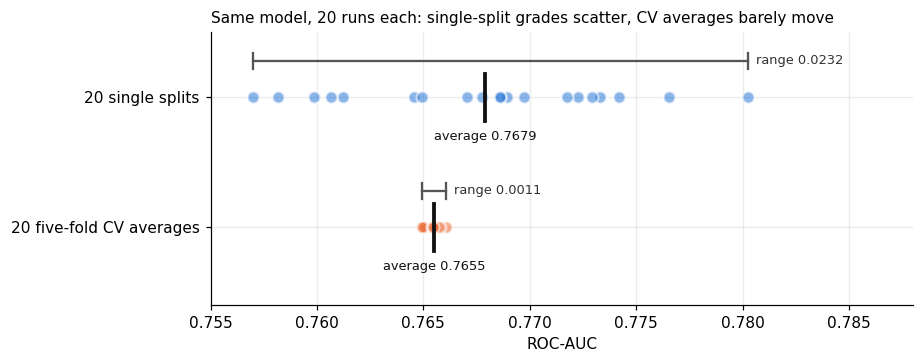

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
for yp, runs, color in [(1, single_split_aucs, BLUE), (0, cv_averages, ORANGE)]:
    ax.scatter(runs, np.full_like(runs, yp), s=60, color=color, alpha=0.55, edgecolor="white", linewidth=1.5, zorder=3)
    # range: a bracket from lowest to highest, labelled with its width
    ax.plot([runs.min(), runs.max()], [yp + 0.28] * 2, color="#555555", linewidth=1.5)
    for x in (runs.min(), runs.max()):
        ax.plot([x, x], [yp + 0.22, yp + 0.34], color="#555555", linewidth=1.5)
    ax.text(runs.max() + 0.0004, yp + 0.28, f"range {runs.max() - runs.min():.4f}", va="center", fontsize=8.5, color="#333333")
    # average: a black tick through the dots, labelled below
    ax.plot([runs.mean()] * 2, [yp - 0.18, yp + 0.18], color="#111111", linewidth=2.5, zorder=4)
    ax.text(runs.mean(), yp - 0.33, f"average {runs.mean():.4f}", ha="center", fontsize=8.5, color="#111111")
ax.set_yticks([1, 0], ["20 single splits", "20 five-fold CV averages"])
ax.set_ylim(-0.6, 1.5); ax.set_xlim(0.755, 0.788)
ax.set_xlabel("ROC-AUC")
ax.set_title("Same model, 20 runs each: single-split grades scatter, CV averages barely move", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** a single split's grade landed anywhere from 0.757 to 0.780, a
range of 0.023, depending only on which clients happened to be hidden. The 5-fold
CV average stayed between 0.7649 and 0.7661, a range of 0.0011, about 20 times
narrower. If you reported one split, you could honestly report either end of the
wider range.

*Why CV is so much steadier:* every 5-fold CV grades all 45,211 clients, each
exactly once. The 20 CV runs only differ in how the clients are grouped. A
single split grades just 9,043 clients, and a different 9,043 each time.

**Conclusion:** report the 5-fold CV average (0.7655 in the version used from
here on), not a single split. It's also why a comparison between two models needs
a gap larger than a single split's wobble before it means anything.

### Part 3 — Leak type 1: a feature known only after the outcome
The dataset's own documentation says this about `duration`, the length of the
call in seconds (quoted verbatim from `data/raw/bank-additional-names.txt`):

> *"this attribute highly affects the output target (e.g., if duration=0 then
> y="no"). Yet, the duration is not known before a call is performed. Also, after
> the end of the call y is obviously known. Thus, this input should only be
> included for benchmark purposes and should be discarded if the intention is to
> have a realistic predictive model."*

Here's what including it does:

In [7]:
cv_duration = cross_val_score(make_pipeline(num=NUM + ["duration"]), df, y, cv=cv, scoring="roc_auc")
print(f"CV AUC without duration: {cv_random.mean():.4f}")
print(f"CV AUC with duration:    {cv_duration.mean():.4f}")
print(f"inflation = {cv_duration.mean():.4f} - {cv_random.mean():.4f} = {cv_duration.mean() - cv_random.mean():+.4f}")
print()
print(f"Median call duration, subscribers:     {df.loc[df['subscribed'] == 1, 'duration'].median():.0f} s")
print(f"Median call duration, non-subscribers: {df.loc[df['subscribed'] == 0, 'duration'].median():.0f} s")
print(f"Calls with duration = 0: {(df['duration'] == 0).sum()}, of which subscribed: {df.loc[df['duration'] == 0, 'subscribed'].sum()}")

CV AUC without duration: 0.7655
CV AUC with duration:    0.9067
inflation = 0.9067 - 0.7655 = +0.1412

Median call duration, subscribers:     426 s
Median call duration, non-subscribers: 164 s
Calls with duration = 0: 3, of which subscribed: 0


**Observation:** adding `duration` lifts CV AUC from 0.7655 to 0.907, a jump of
+0.141. Subscribers' median call is about 2.6 times as long as non-subscribers'
(ratio = 426 / 164 = 2.6).

**Conclusion:** that 0.907 is **not achievable in real use.** The model is meant
to decide *whom to call*, and at that moment the call hasn't happened, so its
length doesn't exist. Nothing in the pipeline code is wrong. The leak lives in
the *question*: which information exists at decision time.

**Mechanism vs cause.** A long call doesn't cause a subscription, and the
dataset can't say which way the arrow runs. **Hypothesis:** clients who are
going to subscribe stay on the line longer to do so (filling in details). Call
recordings or call-stage logs would confirm it; this dataset can't. Either way the column is a
*symptom* of the outcome, which is exactly why it predicts so well and exactly
why it can't be used.

**The check to always run:** for every feature, ask *"at the moment the model
would be used, is this value already known?"* A suspiciously strong feature is
the first thing to question.

### Part 4 — Leak type 2: preprocessing fitted before the split
Two versions of the same mistake. The first turns out nearly harmless; the second doesn't.

**4a. Scaling all rows before cross-validation.** The scaler computes the mean
and standard deviation from *all* rows, test folds included, then CV runs on the
already-scaled data:

In [8]:
X_all = pd.get_dummies(df[NUM + CAT], columns=CAT).astype(float)
X_scaled_on_all_rows = StandardScaler().fit_transform(X_all)          # <- the mistake: fitted before splitting
cv_scaler_leak = cross_val_score(LogisticRegression(max_iter=2000), X_scaled_on_all_rows, y, cv=cv, scoring="roc_auc")
print(f"CV AUC, scaler inside the pipeline (correct): {cv_random.mean():.4f}")
print(f"CV AUC, scaler fitted on all rows (leaky):    {cv_scaler_leak.mean():.4f}")
print(f"difference = {cv_scaler_leak.mean():.4f} - {cv_random.mean():.4f} = {cv_scaler_leak.mean() - cv_random.mean():+.4f}")

CV AUC, scaler inside the pipeline (correct): 0.7655
CV AUC, scaler fitted on all rows (leaky):    0.7656
difference = 0.7656 - 0.7655 = +0.0001


**Observation:** the difference is effectively zero. That's an honest result,
not a failed demo. With 45,211 rows, the mean and standard deviation of 80% of
the rows are almost identical to those of 100%. Very little test information can
leak through two summary numbers per column.

So why does everyone insist on the pipeline? Because some preprocessing steps
learn *much more* from the data than a mean does. The worst are steps that learn
**from the target itself**:

**4b. Target encoding computed on all rows.** *Target encoding* replaces a
category with the average target rate for that category. Here we apply it to
`balance`, treating each exact account balance as a "category". That's a
realistic stand-in for the classic mistake of target-encoding an ID-like column
(customer ID, ZIP code, account number):

In [9]:
df_te = df.copy()
df_te["balance_key"] = df_te["balance"].astype(str)
counts = df_te["balance_key"].map(df_te["balance_key"].value_counts())
print(f"Distinct balance values: {df_te['balance_key'].nunique():,}")
print(f"Rows whose balance value appears only once: {(counts == 1).sum():,} ({(counts == 1).mean():.1%})")

# The mistake: compute each balance value's subscribe rate from ALL rows, then cross-validate
df_te["balance_te_leaky"] = df_te["balance_key"].map(df_te.groupby("balance_key")["subscribed"].mean())
singles = df_te[counts == 1]
print(f"For those once-only rows, does the encoded value equal the row's own label? "
      f"{(singles['balance_te_leaky'] == singles['subscribed']).mean():.0%} of the time")

cv_te_leak = cross_val_score(make_pipeline(num=NUM + ["balance_te_leaky"]), df_te, y, cv=cv, scoring="roc_auc")
# The correct version: TargetEncoder inside the pipeline, so it learns only from training folds
cv_te_correct = cross_val_score(make_pipeline(target_enc=["balance_key"]), df_te, y, cv=cv, scoring="roc_auc")
print(f"\nCV AUC, target encoding inside the pipeline (correct): {cv_te_correct.mean():.4f}")
print(f"CV AUC, target encoding fitted on all rows (leaky):    {cv_te_leak.mean():.4f}")
print(f"inflation = {cv_te_leak.mean():.4f} - {cv_te_correct.mean():.4f} = {cv_te_leak.mean() - cv_te_correct.mean():+.4f}")

Distinct balance values: 7,168
Rows whose balance value appears only once: 2,553 (5.6%)
For those once-only rows, does the encoded value equal the row's own label? 100% of the time



CV AUC, target encoding inside the pipeline (correct): 0.7690
CV AUC, target encoding fitted on all rows (leaky):    0.8712
inflation = 0.8712 - 0.7690 = +0.1022


**Observation:** computed on all rows, target encoding inflates CV AUC from 0.769
to 0.871, a jump of +0.102. The mechanism is visible in the middle line. For the
5.6% of rows whose balance appears only once, the "encoded" value **is** the
row's own label, 100% of the time. The model is being handed the answer for
those rows, and the test folds contain them.

Done correctly, inside the pipeline, the encoding adds nothing: 0.7690 vs 0.7655
without it. So `balance` as an exact value carries no real signal. All of the
leaky version's gain was the answer leaking in.

**Conclusion:** the pipeline habit isn't about the scaler. It's insurance for the
steps that can quietly memorise the target. You don't have to judge case by case
which steps are dangerous if every step lives inside the pipeline.

### Part 5 — Leak type 3: a random split when the job is predicting the future
The rows are in date order (May 2008 to November 2010). A model like this would
be trained on past campaigns and used on the *next* one. A random split doesn't
test that. It trains on calls from every period, including the "future" relative
to many test rows. The honest test for this job is a **time split**: train on the
earliest 80% of rows, test on the latest 20%.

The time version of cross-validation is **forward-chaining** (`TimeSeriesSplit`).
Cut the rows, in date order, into blocks. Train on block 1 and grade on block 2;
then train on blocks 1–2 and grade on block 3; and so on. The model is always
graded on rows that come *after* everything it trained on. With 5 folds, the rows
are cut into **6** blocks, because the first block can only ever be trained on,
never graded: 1/2, 1–2/3, 1–3/4, 1–4/5, 1–5/6.

In [10]:
cut = int(len(df) * 0.8)
past, future = df.iloc[:cut], df.iloc[cut:]
time_split_auc = roc_auc_score(future["subscribed"], make_pipeline().fit(past, past["subscribed"]).predict_proba(future)[:, 1])
print(f"Training rows (earliest {len(past):,}): {past['subscribed'].mean():.1%} said yes   <- a description, not a grade")
print(f"Test rows     (latest {len(future):,}):    {future['subscribed'].mean():.1%} said yes")
print(f"\nAUC, graded on the latest 20% (time split):            {time_split_auc:.4f}")
print(f"AUC, graded on hidden folds (random-split CV, Part 2):  {cv_random.mean():.4f}")
print(f"gap = {time_split_auc:.4f} - {cv_random.mean():.4f} = {time_split_auc - cv_random.mean():+.4f}")

# The same idea as CV: forward-chaining folds, always training on the past and testing on the next block
ts_aucs = cross_val_score(make_pipeline(), df, y, cv=TimeSeriesSplit(n_splits=5), scoring="roc_auc")
print(f"\nTimeSeriesSplit fold AUCs (each trains on everything before its test block): {np.round(ts_aucs, 3).tolist()}")
print(f"  mean = {ts_aucs.mean():.4f}")

Training rows (earliest 36,168): 6.7% said yes   <- a description, not a grade
Test rows     (latest 9,043):    31.6% said yes

AUC, graded on the latest 20% (time split):            0.6833
AUC, graded on hidden folds (random-split CV, Part 2):  0.7655
gap = 0.6833 - 0.7655 = -0.0822



TimeSeriesSplit fold AUCs (each trains on everything before its test block): [0.584, 0.538, 0.486, 0.672, 0.652]
  mean = 0.5865


**Observation:** the subscribe rate in the latest 20% of rows (31.6%) is almost
five times the rate in the earlier 80% (6.7%). A model trained on the past and
tested on the future scores AUC 0.683, well below the random-split CV's 0.7655.
The forward-chaining folds (`TimeSeriesSplit`) are worse still. They range from
0.486 to 0.672, with a mean of 0.5865, and one block scores 0.486, at or just
below a coin flip. What the model learned from earlier calls gives no useful
ranking of that block at all. The earliest folds also train on less data (the first trains on
only the first sixth of the rows), which accounts for part of the drop but not
the below-0.5 fold.

What changed over time? The file in ten equal blocks of consecutive rows:

In [11]:
block = pd.qcut(np.arange(len(df)), 10, labels=[f"{k}0%" for k in range(1, 11)])
drift = pd.DataFrame({
    "first month": df["month"].groupby(block, observed=True).first(),
    "rows": df["subscribed"].groupby(block, observed=True).size(),
    "subscribe rate": df["subscribed"].groupby(block, observed=True).mean().round(3),
    "contact 'unknown'": (df["contact"] == "unknown").groupby(block, observed=True).mean().round(2),
    "previous outcome known": (df["poutcome"] != "unknown").groupby(block, observed=True).mean().round(2),
})
drift.index.name = "rows up to"
drift

,first month,rows,subscribe rate,contact 'unknown',previous outcome known
rows up to,,,,,
10%,may,4522,0.030,1.00,0.00
20%,may,4521,0.037,1.00,0.00
30%,jun,4521,0.048,0.80,0.00
40%,jul,4521,0.064,0.00,0.00
50%,jul,4521,0.061,0.00,0.00
60%,aug,4521,0.062,0.02,0.17
70%,nov,4520,0.105,0.00,0.29
80%,apr,4522,0.131,0.00,0.39
90%,may,4521,0.161,0.00,0.39


**Observation:** three things shift across the file together. The subscribe
rate climbs from 3.0% in the first tenth to 47.1% in the last. `contact` is
"unknown" for every call in the first two tenths and 80% of the third, and
almost never after that. A previous-campaign outcome only exists from the sixth tenth on.
So the late calls differ from the early ones in outcome *and* in what was
recorded about them.

**The same shift on a calendar.** The file has no year column, so the year is
**inferred, not recorded**. The rows are in date order, and every time the month
goes *backwards* (e.g. December to January), a new year has started. That
happens exactly twice, matching the documented span of May 2008 to November 2010.

Times the month goes backwards: 2
Train (earliest 80%): May 2008 to May 2009 (inferred), 36,168 rows
Test  (latest 20%): May 2009 to Nov 2010 (inferred), 9,043 rows
May 2009 is split: 1,991 rows in train, 3,584 in test


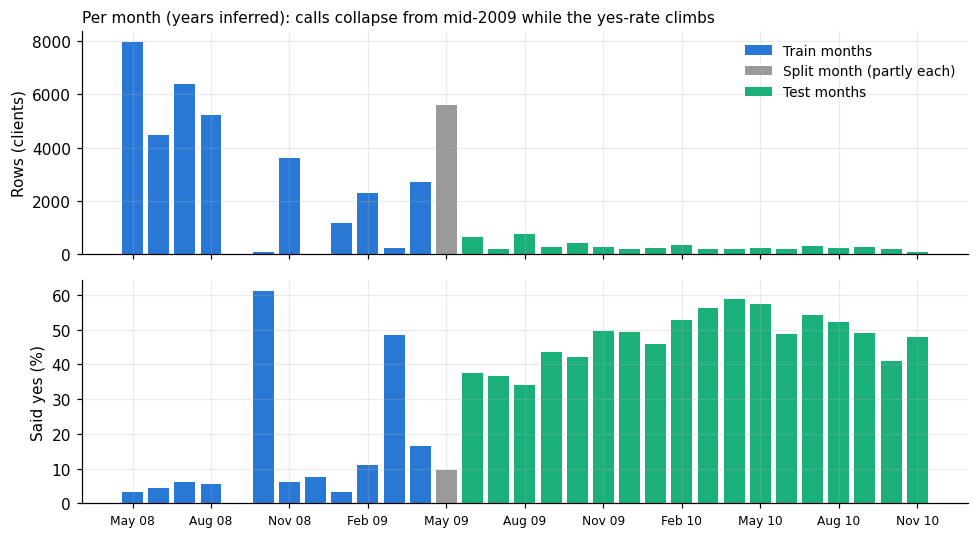

Months with no rows: ['Sep 2008']
Months with under 100 rows (their yes-rate is unreliable):
  Oct 2008: 80 rows, 61% said yes
  Dec 2008: 13 rows, 8% said yes
  Nov 2010: 75 rows, 48% said yes


In [12]:
month_num = df["month"].map({m: i for i, m in enumerate(
    ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"], start=1)})
year = 2008 + (month_num.diff() < 0).cumsum()          # inferred: +1 each time the month goes backwards
print(f"Times the month goes backwards: {(month_num.diff() < 0).sum()}")
period = pd.PeriodIndex.from_fields(year=year, month=month_num, freq="M")
for name, part in [("Train (earliest 80%)", slice(0, cut)), ("Test  (latest 20%)", slice(cut, None))]:
    p = period[part]
    print(f"{name}: {p[0].strftime('%b %Y')} to {p[-1].strftime('%b %Y')} (inferred), {len(p):,} rows")

monthly = df.groupby(period)["subscribed"].agg(calls="size", yes_rate="mean")
monthly = monthly.reindex(pd.period_range("2008-05", "2010-11", freq="M"), fill_value=0)
split_month = period[cut]                                  # the cut falls inside this month
is_test = monthly.index > split_month
is_split = monthly.index == split_month
in_train = (period[:cut] == split_month).sum()
print(f"{split_month.strftime('%b %Y')} is split: {in_train:,} rows in train, {monthly.loc[split_month, 'calls'] - in_train:,} in test")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
x = np.arange(len(monthly))
for ax, values, ylabel in [(ax1, monthly["calls"], "Rows (clients)"), (ax2, monthly["yes_rate"] * 100, "Said yes (%)")]:
    is_train = ~is_test & ~is_split
    ax.bar(x[is_train], values[is_train], color=BLUE, width=0.8, label="Train months")
    ax.bar(x[is_split], values[is_split], color="#9a9a9a", width=0.8, label="Split month (partly each)")
    ax.bar(x[is_test], values[is_test], color=AQUA, width=0.8, label="Test months")
    ax.set_ylabel(ylabel)
ax2.set_xticks(x[::3], [p.strftime("%b %y") for p in monthly.index[::3]], rotation=0, fontsize=8)
ax1.legend(frameon=False, fontsize=9)
ax1.set_title("Per month (years inferred): calls collapse from mid-2009 while the yes-rate climbs", fontsize=10, loc="left")
plt.tight_layout(); plt.show()
print(f"Months with no rows: {[p.strftime('%b %Y') for p in monthly.index[monthly['calls'] == 0]]}")
small = monthly[(monthly["calls"] > 0) & (monthly["calls"] < 100)]
print("Months with under 100 rows (their yes-rate is unreliable):")
for p, r in small.iterrows():
    print(f"  {p.strftime('%b %Y')}: {r['calls']:.0f} rows, {r['yes_rate']:.0%} said yes")

**Observation:** training covers about 12 months (May 2008 to May 2009) and
test about 18 (May 2009 to November 2010). Until May 2009, most months have
thousands of calls; from June 2009, every month has a few hundred at most.
September 2008 has none at all, at the height of the financial crisis. The later
months, all in the test part, have far fewer calls and a far higher yes-rate.
A few months are too small to read on their own: October 2008 (80 rows, 61%
yes), December 2008 (13 rows) and November 2010 (75 rows) jump around because
a handful of clients decide their rate. The steady climb across the test months doesn't depend on
them.

**Hypothesis (not tested here):** the campaign itself changed over time. The
later calls may have been better targeted, or the economic context shifted
(this is 2008–2010, spanning the financial crisis). The data has no year column
and nothing about how clients were selected, so this can't be tested. The
finding holds either way.

**Conclusion:** the random-split 0.7655 is an optimistic estimate *for this use*.
Any model used to predict a future period should be judged on a time split. The
random split's error isn't a coding bug. It answers a different question ("how
well does the model rank rows drawn from the same mix of periods it was trained
on?").

*A scope note:* modules 2–6 use the credit data, which is a single snapshot with
no time order. So a random (stratified) split is the right design there, and
this caveat moves into Module 6's list of "where not to trust the score".

**Rigor check: is the gap specific to this model?** A different model family (a
gradient-boosted tree model, which Module 3's territory covers properly) on the
same split designs:

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
X_cat = df.drop(columns=["subscribed", "duration"]).copy()
for c in X_cat.select_dtypes("object"):
    X_cat[c] = X_cat[c].astype("category")
hgb = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0)
hgb_random = cross_val_score(hgb, X_cat, y, cv=cv, scoring="roc_auc").mean()
hgb_time = roc_auc_score(y.iloc[cut:], hgb.fit(X_cat.iloc[:cut], y.iloc[:cut]).predict_proba(X_cat.iloc[cut:])[:, 1])
print(f"Gradient-boosted trees: random-split CV AUC {hgb_random:.4f}, time-split AUC {hgb_time:.4f}")
print(f"  gap = {hgb_time:.4f} - {hgb_random:.4f} = {hgb_time - hgb_random:+.4f}")

# How big is sampling noise in a 9,043-row AUC? Bootstrap: resample the test rows with replacement, recompute AUC.
future_scores = make_pipeline().fit(past, past["subscribed"]).predict_proba(future)[:, 1]
rng_boot = np.random.default_rng(7)
yf = future["subscribed"].to_numpy()
boot = [roc_auc_score(yf[idx], future_scores[idx])
        for idx in (rng_boot.integers(0, len(yf), len(yf)) for _ in range(300))]
print(f"\nBootstrap of the logistic time-split AUC (300 resamples): standard deviation = {np.std(boot):.4f}")

Gradient-boosted trees: random-split CV AUC 0.7973, time-split AUC 0.6594
  gap = 0.6594 - 0.7973 = -0.1379



Bootstrap of the logistic time-split AUC (300 resamples): standard deviation = 0.0062


**Observation:** the gap is there with a different model too, and larger.
**Conclusion:** the gap comes from the data changing over time, not from a quirk
of logistic regression. And it isn't sampling noise. Re-drawing the 9,043 test
rows at random, 300 times, moves the AUC by a standard deviation of about
0.006. That's a small fraction of the gaps, which are 0.08 (logistic) and
0.14 (boosted trees). In plain English: if we'd happened to get a different
9,043 future calls from the same period, the AUC would typically shift by about
0.006, nowhere near enough to close a gap of 0.08.

### Part 6 — All the estimates, side by side

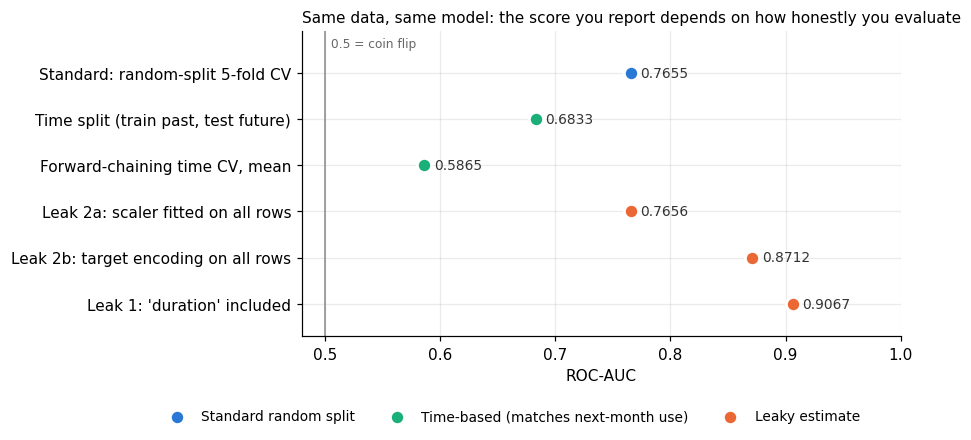

In [14]:
results = pd.DataFrame([
    ("Standard: random-split 5-fold CV",             cv_random.mean(),     "standard"),
    ("Time split (train past, test future)",         time_split_auc,       "time"),
    ("Forward-chaining time CV, mean",               ts_aucs.mean(),       "time"),
    ("Leak 2a: scaler fitted on all rows",           cv_scaler_leak.mean(), "leaky"),
    ("Leak 2b: target encoding on all rows",         cv_te_leak.mean(),    "leaky"),
    ("Leak 1: 'duration' included",                  cv_duration.mean(),   "leaky"),
], columns=["setup", "auc", "kind"])

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ypos = np.arange(len(results))[::-1]
for kind, color, label in [("standard", BLUE, "Standard random split"),
                           ("time", AQUA, "Time-based (matches next-month use)"),
                           ("leaky", ORANGE, "Leaky estimate")]:
    mask = (results["kind"] == kind).to_numpy()
    ax.scatter(results["auc"][mask], ypos[mask], s=90, color=color, edgecolor="white", linewidth=2, zorder=3, label=label)
for yp, v in zip(ypos, results["auc"]):
    ax.text(v + 0.008, yp, f"{v:.4f}", va="center", fontsize=9, color="#333333")
ax.axvline(0.5, color="#888888", linewidth=1)
ax.text(0.505, ypos.max() + 0.55, "0.5 = coin flip", fontsize=8, color="#666666")
ax.set_yticks(ypos, results["setup"]); ax.set_xlim(0.48, 1.0); ax.set_ylim(-0.7, ypos.max() + 0.9)
ax.set_xlabel("ROC-AUC")
ax.set_title("Same data, same model: the score you report depends on how honestly you evaluate", fontsize=10, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.35, -0.2), ncol=3, frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**Observation:** the same model and data give an AUC anywhere from 0.5865 to
0.907, depending only on evaluation choices. The two leaks that matter both beat
the standard random-split estimate by 0.10 or more. The honest estimates for the
real use case (the two time-based ones) are the lowest numbers on the chart.

## Exercises

### Exercise 1 — Find the leak
You're building a model to predict, **on the 1st of each month**, which credit
card holders will default during that month. Classify each candidate as **safe**
or **leaky**, and say why.

| # | Candidate | Verdict | Why |
|---|-----------|---------|-----|
| a | Number of collection calls made to the client *this month* | **Leaky** | Collection calls are made *because* a payment was missed. It's a consequence of the outcome, like `duration`. |
| b | `StandardScaler` inside a `Pipeline`, fitted with `pipe.fit(X_train, y_train)` | **Safe** | The scaler learns only from training rows. |
| c | Missing incomes filled with the median income of the *whole* dataset, computed before splitting | **Leaky (mildly)** | Test rows shape a value the model trains on. Usually tiny in effect, like Part 4a, but wrong in principle, and free to fix: put `SimpleImputer` in the pipeline. |
| d | The client's repayment status *last* month | **Safe** | Known on the 1st of the month, before the outcome. |
| e | Default rate of the client's branch, computed over all rows | **Leaky (mildly)** | The hidden clients' answers are part of the rate. With hundreds of clients per branch, each one barely moves it, so the effect is small, but it's wrong in principle and free to fix: compute it inside the pipeline. It becomes serious for tiny groups, like the one-of-a-kind balances in Part 4b. |
| f | A random 80/20 split, when the model will score next month's clients | **Leaky (evaluation)** | It tests on the same periods it trained on (Part 5). Use a time split: train on months 1–10, test on months 11–12. |

### Exercise 2 — "Our model has 99% accuracy"
*A colleague's fraud model has 99% accuracy. What do you check first?*

1. **The base rate.** If 1% of transactions are fraud, predicting "never fraud"
   scores 99% (Part 1's trap at a more extreme ratio). Ask for AUC, or precision
   and recall (Module 4).
2. **The strongest features.** For each: is it known at decision time (Part 3)?
   A dispute or chargeback flag, for example, only exists *after* fraud is found.
3. **The split.** Random or by time? Fraud patterns shift, so the honest test is
   on a later period (Part 5).
4. **The preprocessing.** Are all fitted steps inside a pipeline, especially any
   target-based encoding (Part 4b)?

## Key takeaways

- **Conclusion:** judge a model only on rows that played no part in building it,
  and report the CV mean, not a single split. One split's AUC moved by 0.023
  purely from the random seed.
- **Conclusion:** a feature known only after the outcome (`duration`) inflated
  AUC by +0.141. Nothing in the code catches this. Only asking "is this known at
  decision time?" does.
- **Conclusion:** preprocessing fitted before the split ranges from harmless
  (scaling, +0.000) to severe (target encoding, +0.102). A `Pipeline` removes the
  need to guess which kind you have.
- **Conclusion:** a random split overstated performance for predicting a future
  period: 0.7655 random, vs 0.683 on a
  single time split and 0.5865 averaged over forward-chaining folds.
- **Hypothesis:** the time-split gap reflects a change in how the campaign was
  run, or in its context, across 2008–2010. It's untestable with this data.